# CAPTSTONE PROJECT 3 - Predicting Employee Burnout using Machine Learning
<hr><hr>

# Author - *Ifeanyi Ike*
<hr>

## Employee Burnout and Its Organizational Impacts

### What is Employee Burnout?
Employee burnout is a state of emotional, physical, and mental exhaustion caused by prolonged and excessive workplace stress. It often occurs when employees feel overwhelmed, emotionally drained, and unable to meet constant demands. Over time, burnout reduces productivity, saps energy, and can lead to disengagement, cynicism, and a decline in job performance.

### Organizational Impacts of Employee Burnout
**1. Decreased Productivity**:
Burnout leads to lower energy levels and focus, causing employees to underperform. Tasks take longer to complete, mistakes increase, and overall work quality declines.

**2. Higher Turnover Rates**:
Employees experiencing burnout are more likely to resign. This increases recruitment costs and disrupts continuity in team performance and company operations.

**3. Increased Absenteeism and Presenteeism**:
Burnout can cause employees to take frequent sick leaves (absenteeism) or show up to work while unwell and disengaged (presenteeism), reducing overall workplace efficiency.

**4. Poor Workplace Morale**:
Burned-out employees often experience irritability, frustration, and detachment. This can negatively affect team dynamics, leading to conflict and a toxic work culture.

**5. Greater Healthcare Costs**:
Burnout is closely linked with mental health conditions such as anxiety and depression, which can increase organizational spending on employee health benefits and insurance claims.

**6. Reduced Innovation and Creativity**:
A fatigued and disengaged workforce is less likely to contribute new ideas, take initiative, or solve problems creatively, hampering the organization's ability to grow or remain competitive.

**7. Reputation and Employer Branding Issues**:
High levels of employee burnout can lead to poor reviews on platforms like Glassdoor, which damages the organization’s reputation and makes it harder to attract top talent.

Addressing employee burnout is not only essential for safeguarding the well-being of staff but also for preserving the long-term sustainability, efficiency, and competitiveness of the organization.


## The Importance of Using Data to Predict and Prevent Burnout

Using data to predict and prevent employee burnout is essential in today’s data-driven workplace. As burnout can lead to significant organizational and personal consequences, leveraging data provides a proactive, evidence-based approach to identify risks early and take corrective actions.

### Why Using Data Matters in Preventing Burnout
- **Early Detection of Warning Signs**: <br>
By analyzing patterns such as declining productivity, increased absenteeism, longer working hours, or changes in engagement scores, organizations can detect early signs of burnout before it becomes severe.

- **Objective Decision-Making**: <br>
Data-driven insights help leaders make informed decisions rather than relying on assumptions or subjective impressions. This ensures fairness and accuracy in identifying at-risk employees.

- **Personalized Interventions**: <br>
Data allows for tailoring interventions based on individual or departmental needs. For instance, employees showing signs of cognitive fatigue may benefit from reduced workloads, while others may need flexible work arrangements.

- **Tracking the Effectiveness of Wellness Programs**: <br>
Data analytics helps measure the success of employee wellness and engagement initiatives over time. This enables continuous improvement of HR strategies aimed at preventing burnout.

- **Resource Allocation**: <br>
Organizations can allocate mental health resources, training programs, and managerial support more efficiently by understanding where burnout risk is highest.

- **Strengthening Company Culture**: <br>
Regularly collecting and analyzing employee sentiment data promotes a culture of listening, responsiveness, and accountability, which fosters trust and reduces burnout risk.

- **Improved Retention and Engagement**: <br>
Predictive models help organizations identify burnout trends that lead to turnover. Acting on this data improves employee satisfaction and retention.

Using data to predict and prevent burnout transforms how organizations support their workforce. It empowers leaders to take timely, targeted action that enhances employee well-being, boosts morale, and drives long-term organizational success.
<hr><hr>

### Import Libraries

In [3]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [4]:
# load train.csv and test.csv datasets
train_df = pd.read_csv('train.csv')

test_df = pd.read_csv('test.csv')

## Data Overview

In [5]:
train_df.head()

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52


In [6]:
test_df.head()

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score
0,fffe31003300390039003000,2008-12-10,Female,Service,No,2.0,5.0,7.7
1,fffe31003300310037003800,2008-08-14,Female,Product,Yes,1.0,2.0,5.2
2,fffe33003400380035003900,2008-11-13,Male,Product,Yes,1.0,3.0,5.9
3,fffe3100370039003200,2008-02-07,Female,Service,No,3.0,6.0,4.6
4,fffe32003600390036003700,2008-07-17,Female,Product,No,2.0,5.0,6.4


In [7]:
# converting all column names to lower case + replacing spaces with underscores
train_df.columns = train_df.columns.str.strip().str.lower().str.replace(' ', '_')
train_df.columns

Index(['employee_id', 'date_of_joining', 'gender', 'company_type',
       'wfh_setup_available', 'designation', 'resource_allocation',
       'mental_fatigue_score', 'burn_rate'],
      dtype='object')

In [8]:
# converting all column names to lower case + replacing spaces with underscores
test_df.columns = test_df.columns.str.strip().str.lower().str.replace(' ', '_')
test_df.columns

Index(['employee_id', 'date_of_joining', 'gender', 'company_type',
       'wfh_setup_available', 'designation', 'resource_allocation',
       'mental_fatigue_score'],
      dtype='object')

In [9]:
# Set the employee_id as the index of the dataframes
train_df.set_index('employee_id', inplace=True)
test_df.set_index('employee_id', inplace=True)

In [10]:
# Rename columns
train_df = train_df.rename({'wfh_setup_available': 'work_remotely'}, axis=1)
test_df = test_df.rename({'wfh_setup_available': 'work_remotely'}, axis=1)

In [11]:
train_df.head()

,date_of_joining,gender,company_type,work_remotely,designation,resource_allocation,mental_fatigue_score,burn_rate
employee_id,,,,,,,,
fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,NaN,5.8,0.49
fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20
fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52


In [12]:
test_df.head()

,date_of_joining,gender,company_type,work_remotely,designation,resource_allocation,mental_fatigue_score
employee_id,,,,,,,
fffe31003300390039003000,2008-12-10,Female,Service,No,2.0,5.0,7.7
fffe31003300310037003800,2008-08-14,Female,Product,Yes,1.0,2.0,5.2
fffe33003400380035003900,2008-11-13,Male,Product,Yes,1.0,3.0,5.9
fffe3100370039003200,2008-02-07,Female,Service,No,3.0,6.0,4.6
fffe32003600390036003700,2008-07-17,Female,Product,No,2.0,5.0,6.4


In [13]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22750 entries, fffe32003000360033003200 to fffe3400350031003800
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date_of_joining       22750 non-null  object 
 1   gender                22750 non-null  object 
 2   company_type          22750 non-null  object 
 3   work_remotely         22750 non-null  object 
 4   designation           22750 non-null  float64
 5   resource_allocation   21369 non-null  float64
 6   mental_fatigue_score  20633 non-null  float64
 7   burn_rate             21626 non-null  float64
dtypes: float64(4), object(4)
memory usage: 1.6+ MB


In [14]:
train_df.shape

(22750, 8)

In [90]:
train_df.columns

Index(['date_of_joining', 'gender', 'company_type', 'work_remotely',
       'designation', 'resource_allocation', 'mental_fatigue_score',
       'burn_rate'],
      dtype='object')

In [91]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12250 entries, fffe31003300390039003000 to fffe32003100390037003800
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date_of_joining       12250 non-null  object 
 1   gender                12250 non-null  object 
 2   company_type          12250 non-null  object 
 3   work_remotely         12250 non-null  object 
 4   designation           12250 non-null  float64
 5   resource_allocation   12250 non-null  float64
 6   mental_fatigue_score  12250 non-null  float64
dtypes: float64(3), object(4)
memory usage: 765.6+ KB


In [92]:
test_df.shape

(12250, 7)

In [93]:
test_df.columns

Index(['date_of_joining', 'gender', 'company_type', 'work_remotely',
       'designation', 'resource_allocation', 'mental_fatigue_score'],
      dtype='object')

In [94]:
# Summary statistics of the train dataset numerical variables
train_df.describe()

,designation,resource_allocation,mental_fatigue_score,burn_rate
count,22750.000000,21369.000000,20633.000000,21626.000000
mean,2.178725,4.481398,5.728188,0.452005
std,1.135145,2.047211,1.920839,0.198226
min,0.000000,1.000000,0.000000,0.000000
25%,1.000000,3.000000,4.600000,0.310000
50%,2.000000,4.000000,5.900000,0.450000
75%,3.000000,6.000000,7.100000,0.590000
max,5.000000,10.000000,10.000000,1.000000


In [95]:
# Summary statistics of the train dataset categorical variables
train_df.describe(include='object')

,date_of_joining,gender,company_type,work_remotely
count,22750,22750,22750,22750
unique,366,2,2,2
top,2008-01-06,Female,Service,Yes
freq,86,11908,14833,12290


In [96]:
# Summary statistics of the test dataset numerical variables
test_df.describe()

,designation,resource_allocation,mental_fatigue_score
count,12250.000000,12250.000000,12250.000000
mean,2.175265,4.458857,5.720571
std,1.132885,2.045602,1.914063
min,0.000000,1.000000,0.000000
25%,1.000000,3.000000,4.500000
50%,2.000000,4.000000,5.900000
75%,3.000000,6.000000,7.100000
max,5.000000,10.000000,10.000000


In [97]:
# Summary statistics of the test dataset categorical variables
test_df.describe(include='object')

,date_of_joining,gender,company_type,work_remotely
count,12250,12250,12250,12250
unique,366,2,2,2
top,2008-07-19,Female,Service,Yes
freq,51,6445,8004,6638


In [133]:
# Value_counts of the categorical columns in train_df
cat_df = train_df.select_dtypes(include='object').columns
for col in cat_df:
    print("*"*5, col, "*"*5)
    count = train_df[col].value_counts()
    print(count)
    print()

***** date_of_joining *****
date_of_joining
2008-01-06    86
2008-05-21    85
2008-02-04    82
2008-07-16    81
2008-07-13    80
              ..
2008-06-27    44
2008-07-06    44
2008-07-04    43
2008-12-24    43
2008-12-07    39
Name: count, Length: 366, dtype: int64

***** gender *****
gender
Female    11908
Male      10842
Name: count, dtype: int64

***** company_type *****
company_type
Service    14833
Product     7917
Name: count, dtype: int64

***** work_remotely *****
work_remotely
Yes    12290
No     10460
Name: count, dtype: int64



In [134]:
# Value_counts of the categorical columns in test_df
cat_df = test_df.select_dtypes(include='object').columns
for col in cat_df:
    print("*"*5, col, "*"*5)
    count = test_df[col].value_counts()
    print(count)
    print()

***** date_of_joining *****
date_of_joining
2008-07-19    51
2008-08-22    48
2008-03-31    47
2008-10-05    47
2008-11-20    46
              ..
2008-06-04    21
2008-02-06    19
2008-06-09    18
2008-04-13    18
2008-05-11    18
Name: count, Length: 366, dtype: int64

***** gender *****
gender
Female    6445
Male      5805
Name: count, dtype: int64

***** company_type *****
company_type
Service    8004
Product    4246
Name: count, dtype: int64

***** work_remotely *****
work_remotely
Yes    6638
No     5612
Name: count, dtype: int64



## Standardize Formats

In [100]:
train_df.dtypes

date_of_joining          object
gender                   object
company_type             object
work_remotely            object
designation             float64
resource_allocation     float64
mental_fatigue_score    float64
burn_rate               float64
dtype: object

In [15]:
## Standardizing the date format

# Convert date_of_joining to datetime format
train_df['date_of_joining'] = pd.to_datetime(train_df['date_of_joining'], errors='coerce')

In [16]:
train_df.dtypes

date_of_joining         datetime64[ns]
gender                          object
company_type                    object
work_remotely                   object
designation                    float64
resource_allocation            float64
mental_fatigue_score           float64
burn_rate                      float64
dtype: object

In [17]:
## Standardizing the date format on the test dataset

# Convert date_of_joining to datetime format
test_df['date_of_joining'] = pd.to_datetime(test_df['date_of_joining'], errors='coerce')

In [18]:
test_df.dtypes

date_of_joining         datetime64[ns]
gender                          object
company_type                    object
work_remotely                   object
designation                    float64
resource_allocation            float64
mental_fatigue_score           float64
dtype: object

## Data Cleaning and Preprocessing

In [19]:
# identify missing values
train_df.isnull().sum()

date_of_joining            0
gender                     0
company_type               0
work_remotely              0
designation                0
resource_allocation     1381
mental_fatigue_score    2117
burn_rate               1124
dtype: int64

**Comment**: We can see that from our analysis we have missing values in resource_allocation, mental_fatique_score, and burn_rate. We'll go ahead and handle these missing values.

In [21]:
test_df.isnull().sum()

date_of_joining         0
gender                  0
company_type            0
work_remotely           0
designation             0
resource_allocation     0
mental_fatigue_score    0
dtype: int64

**Comment**: No missing value in the test dataset.

In [20]:
train_df.isnull().mean() * 100

date_of_joining         0.000000
gender                  0.000000
company_type            0.000000
work_remotely           0.000000
designation             0.000000
resource_allocation     6.070330
mental_fatigue_score    9.305495
burn_rate               4.940659
dtype: float64

In [22]:
# number of columns with all missing values
train_df.isnull().all(axis=0).sum()

np.int64(0)

In [109]:
# number of rows with all missing values
train_df.isnull().all(axis=1).sum()

np.int64(0)

In [23]:
# checking rows with more than 2 missing values. if there is, we remove them
nan_rows = train_df[train_df.isnull().sum(axis=1) >= 3]
nan_rows.count(axis=0)

date_of_joining         15
gender                  15
company_type            15
work_remotely           15
designation             15
resource_allocation      0
mental_fatigue_score     0
burn_rate                0
dtype: int64

**Comment**: There are 15 rows with more than 2 missing values in them. We'll drop these rows because they will not be important in our analysis.

In [111]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22750 entries, fffe32003000360033003200 to fffe3400350031003800
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date_of_joining       22750 non-null  datetime64[ns]
 1   gender                22750 non-null  object        
 2   company_type          22750 non-null  object        
 3   work_remotely         22750 non-null  object        
 4   designation           22750 non-null  float64       
 5   resource_allocation   21369 non-null  float64       
 6   mental_fatigue_score  20633 non-null  float64       
 7   burn_rate             21626 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(3)
memory usage: 2.1+ MB


### Handling Missing Values on the `train_df` dataset

In [24]:
# dropping the rows with more than 2 missing values
train_df.drop(train_df[train_df.isnull().sum(axis=1) >= 3].index, inplace=True)
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22735 entries, fffe32003000360033003200 to fffe3400350031003800
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date_of_joining       22735 non-null  datetime64[ns]
 1   gender                22735 non-null  object        
 2   company_type          22735 non-null  object        
 3   work_remotely         22735 non-null  object        
 4   designation           22735 non-null  float64       
 5   resource_allocation   21369 non-null  float64       
 6   mental_fatigue_score  20633 non-null  float64       
 7   burn_rate             21626 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(3)
memory usage: 1.6+ MB


**Comment**: Now that we have dropped rows with more than 2 missing values, we'll go ahead to handle missing values using SimpleImputer method (Median).

### Handling Missing Values

### Filling the missing values using SimpleImputer method (Median)

In [25]:
# check for missing values again
train_df.isnull().sum()

date_of_joining            0
gender                     0
company_type               0
work_remotely              0
designation                0
resource_allocation     1366
mental_fatigue_score    2102
burn_rate               1109
dtype: int64

In [26]:
# filling missing values with median
num_cols = train_df.select_dtypes(include='number').columns

train_df[num_cols] = train_df[num_cols].fillna(train_df[num_cols].median())

In [27]:
train_df.isnull().sum()

date_of_joining         0
gender                  0
company_type            0
work_remotely           0
designation             0
resource_allocation     0
mental_fatigue_score    0
burn_rate               0
dtype: int64

**Comment**: We have successfully handled the missing values by filling them with the `median`.

### Checking for duplicates

In [28]:
# check for duplicate rows
train_df.duplicated().sum()

np.int64(11)

**Comment**: We found `11` duplicate rows. We'll handle this by removing the duplicated rows

### Dropping duplicate rows

In [29]:
# dropping duplicate rows
train_df.drop_duplicates(keep='first', inplace=True)

In [30]:
# check for duplicate rows
train_df.duplicated().sum()

np.int64(0)

In [31]:
# Checking for duplicates in the test dataset
test_df.duplicated().sum()

np.int64(40)

**Comment**: We found `40` duplicate rows in the test dataset. We'll go ahead to remove the duplicates.

In [32]:
test_df.drop_duplicates(keep='first', inplace=True)

In [33]:
# Checking for duplicates in the test dataset
test_df.duplicated().sum()

np.int64(0)

**Comment**: Successfully removed the detected duplicates.

## Outlier Detection and Treatment in the `train` dataset

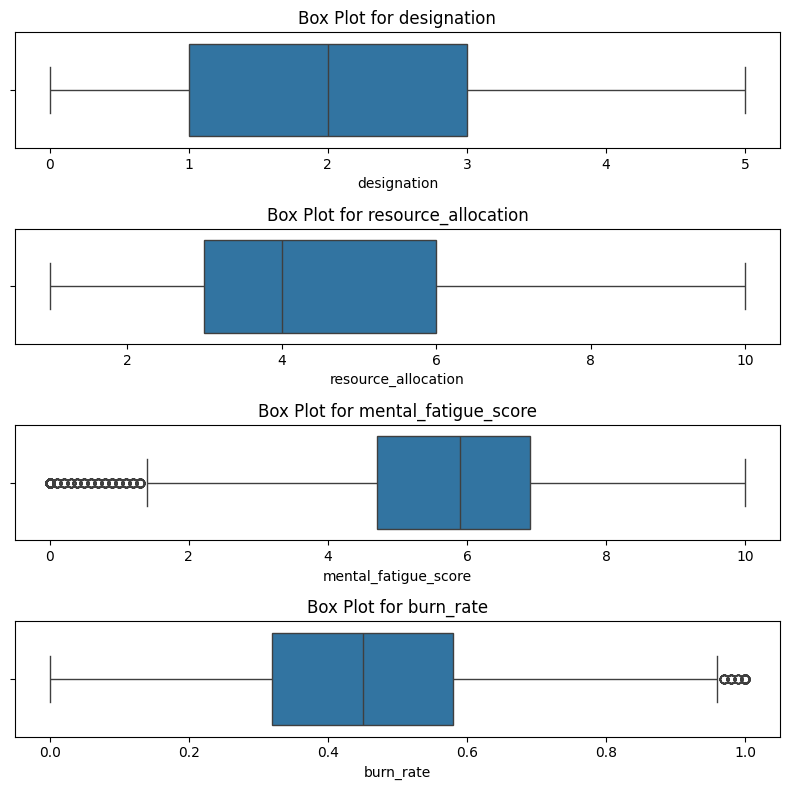

In [34]:
## Detecting outliers on numerical columns

# Filter numerical columns for box plots
numerical_features = train_df.select_dtypes(include=['number']).columns

# Plot box plots for each numerical feature
plt.figure(figsize=(8, len(numerical_features) * 2))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(len(numerical_features), 1, i)
    sns.boxplot(x=train_df[col])
    plt.title(f"Box Plot for {col}")
    plt.tight_layout()

plt.show()

#the job of enumerate(numerical_features, 1)
#is to loop over the list 'numerical_features' while also keeping track of an index i starting from 1.

### Handling the minimal outliers found in `mental_fatique_score` and `burn_rate`

In [35]:
# Define the IQR Outlier Removal Function
def remove_outliers_iqr(train_df, column):
    Q1 = train_df[column].quantile(0.25)
    Q3 = train_df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return train_df[(train_df[column] >= lower_bound) & (train_df[column] <= upper_bound)]

train_df = train_df
numerical_columns = train_df.select_dtypes(include=['number']).columns

for col in numerical_columns:
    train_df = remove_outliers_iqr(train_df, col)

In [36]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22076 entries, fffe32003000360033003200 to fffe3400350031003800
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date_of_joining       22076 non-null  datetime64[ns]
 1   gender                22076 non-null  object        
 2   company_type          22076 non-null  object        
 3   work_remotely         22076 non-null  object        
 4   designation           22076 non-null  float64       
 5   resource_allocation   22076 non-null  float64       
 6   mental_fatigue_score  22076 non-null  float64       
 7   burn_rate             22076 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(3)
memory usage: 1.5+ MB


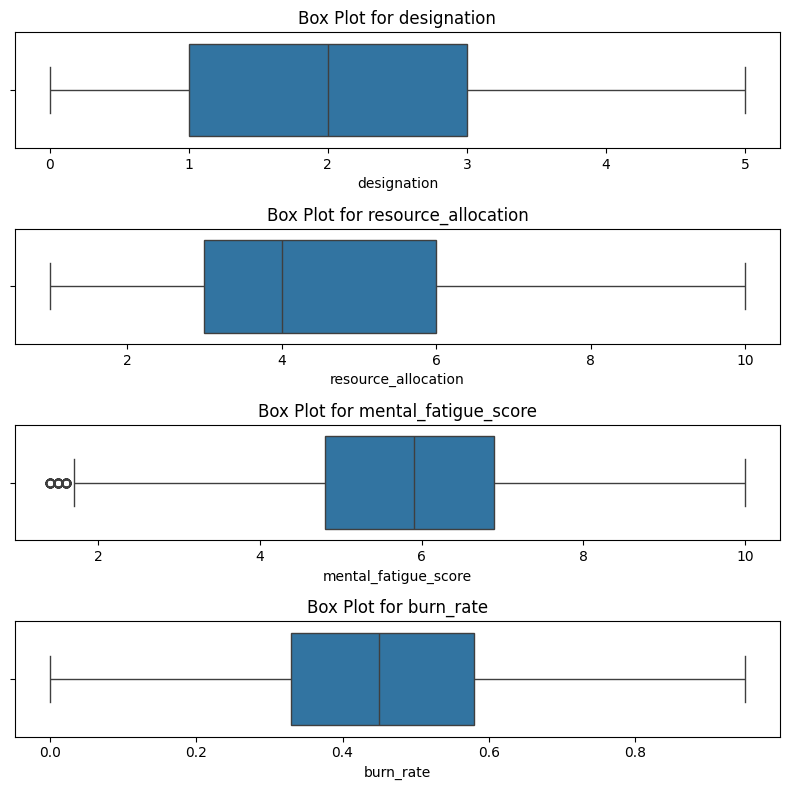

In [37]:
## Recheck outliers

# Filter numerical columns for box plots
numerical_features = train_df.select_dtypes(include=['number']).columns

# Plot box plots for each numerical feature
plt.figure(figsize=(8, len(numerical_features) * 2))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(len(numerical_features), 1, i)
    sns.boxplot(x=train_df[col])
    plt.title(f"Box Plot for {col}")
    plt.tight_layout()

plt.show()

#the job of enumerate(numerical_features, 1)
#is to loop over the list 'numerical_features' while also keeping track of an index i starting from 1.

**Comment**: Outlier successfully handled!

In [38]:
train_df.describe()

,date_of_joining,designation,resource_allocation,mental_fatigue_score,burn_rate
count,22076,22076.000000,22076.000000,22076.000000,22076.000000
mean,2008-07-01 07:49:39.017937920,2.204430,4.497192,5.842163,0.457818
min,2008-01-01 00:00:00,0.000000,1.000000,1.400000,0.000000
25%,2008-04-01 00:00:00,1.000000,3.000000,4.800000,0.330000
50%,2008-07-02 00:00:00,2.000000,4.000000,5.900000,0.450000
75%,2008-09-30 00:00:00,3.000000,6.000000,6.900000,0.580000
max,2008-12-31 00:00:00,5.000000,10.000000,10.000000,0.950000
std,NaN,1.103734,1.920962,1.648967,0.180428


## Outlier Detection and Treatment in the `test` dataset

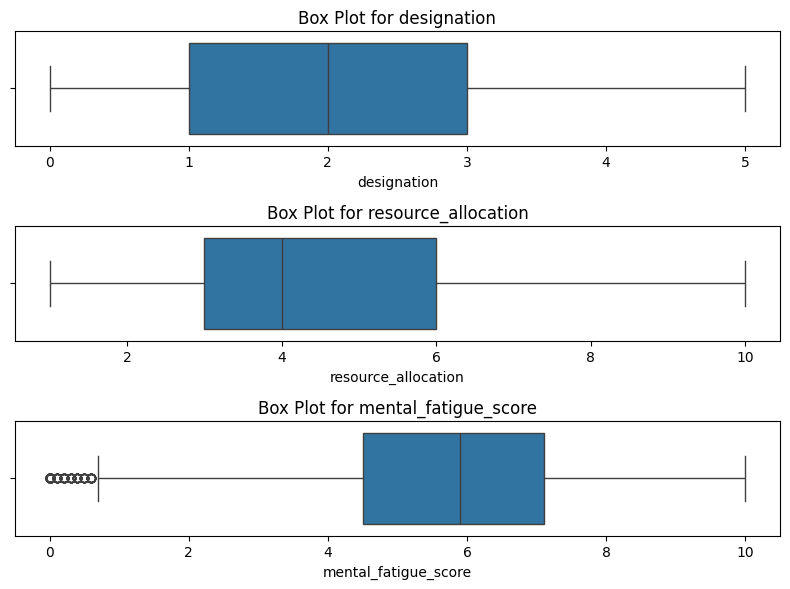

In [39]:
## Detecting outliers on numerical columns

# Filter numerical columns for box plots
numerical_features = test_df.select_dtypes(include=['number']).columns

# Plot box plots for each numerical feature
plt.figure(figsize=(8, len(numerical_features) * 2))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(len(numerical_features), 1, i)
    sns.boxplot(x=test_df[col])
    plt.title(f"Box Plot for {col}")
    plt.tight_layout()

plt.show()

#the job of enumerate(numerical_features, 1)
#is to loop over the list 'numerical_features' while also keeping track of an index i starting from 1.

### Handling the outliers found in the lower bound of `mental_fatigue_score` variable

In [164]:
# Define the IQR Outlier Removal Function
def remove_outliers_iqr(test_df, column):
    Q1 = test_df[column].quantile(0.25)
    Q3 = test_df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return test_df[(test_df[column] >= lower_bound) & (test_df[column] <= upper_bound)]

test_df = test_df
numerical_columns = test_df.select_dtypes(include=['number']).columns

for col in numerical_columns:
    test_df = remove_outliers_iqr(test_df, col)

In [166]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12056 entries, fffe31003300390039003000 to fffe32003100390037003800
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date_of_joining       12056 non-null  datetime64[ns]
 1   gender                12056 non-null  object        
 2   company_type          12056 non-null  object        
 3   work_remotely         12056 non-null  object        
 4   designation           12056 non-null  float64       
 5   resource_allocation   12056 non-null  float64       
 6   mental_fatigue_score  12056 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 1011.5+ KB


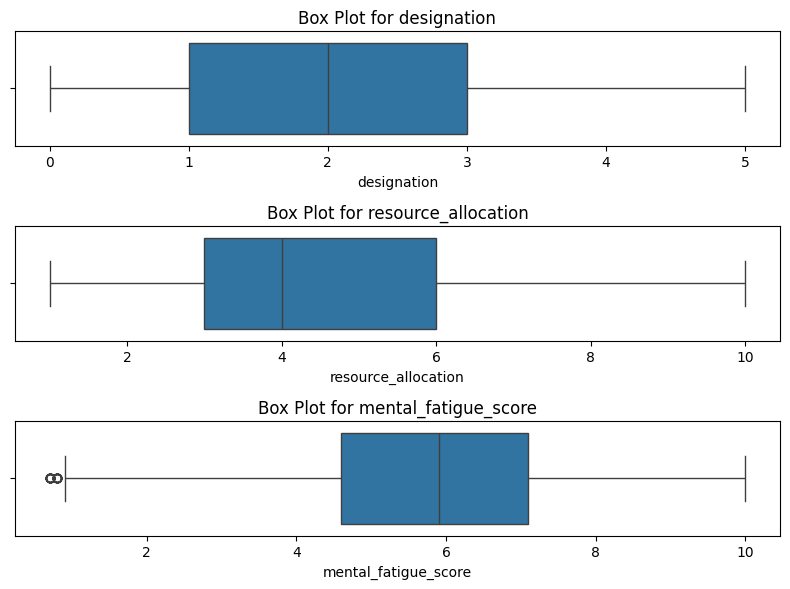

In [165]:
# Rechecking for outliers

# Filter numerical columns for box plots
numerical_features = test_df.select_dtypes(include=['number']).columns

# Plot box plots for each numerical feature
plt.figure(figsize=(8, len(numerical_features) * 2))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(len(numerical_features), 1, i)
    sns.boxplot(x=test_df[col])
    plt.title(f"Box Plot for {col}")
    plt.tight_layout()

plt.show()

#the job of enumerate(numerical_features, 1)
#is to loop over the list 'numerical_features' while also keeping track of an index i starting from 1.

**Comment**: Outliers handled. We now a clean dataset to work with.

## Exploratory Data Analysis (EDA)

## Univariate Analysis

### Checking for skewness

In [40]:
from scipy.stats import skew

## Checking for skewness in the numerical columns

# Select numeric columns
numerical_columns = train_df.select_dtypes(include=['number']).columns

# Calculate skewness
skewness = train_df[numerical_columns].apply(lambda x: x.skew()).sort_values(ascending=False)

# View highly skewed features (e.g., skewness > 1)
skewed_features = skewness[skewness < 0.5]
print(skewed_features)

resource_allocation     0.236211
burn_rate               0.091674
designation             0.083072
mental_fatigue_score   -0.179654
dtype: float64


In [41]:
# linear relationship between numerical variables and the target variable (burn_rate)
train_df.corr(numeric_only=True)['burn_rate'].sort_values(ascending=False)

burn_rate               1.000000
mental_fatigue_score    0.868019
resource_allocation     0.795899
designation             0.696532
Name: burn_rate, dtype: float64

**Insight**: Our analysis shows that the numerical columns has strong correlation with the target variable `(burn_rate)`, meaning that as the `mental_fatigue_score`, `resource_allocation`, and `designation` increase, the `burn_rate` tends to increase. This is good for a regression model.

In [42]:
## let's create a function for numerical analysis

# Select numeric columns
num_df = train_df.select_dtypes(include=['number'])

def num_univariate_analysis(discrete_data):
    for col_name in discrete_data:
        print("*"*5, col_name, "*"*5)
        print(discrete_data[col_name].agg(['min', 'max', 'mean', 'median', 'std', 'kurt', 'skew']))
        print()

num_univariate_analysis(num_df)

***** designation *****
min       0.000000
max       5.000000
mean      2.204430
median    2.000000
std       1.103734
kurt     -0.389620
skew      0.083072
Name: designation, dtype: float64

***** resource_allocation *****
min        1.000000
max       10.000000
mean       4.497192
median     4.000000
std        1.920962
kurt      -0.321350
skew       0.236211
Name: resource_allocation, dtype: float64

***** mental_fatigue_score *****
min        1.400000
max       10.000000
mean       5.842163
median     5.900000
std        1.648967
kurt      -0.120080
skew      -0.179654
Name: mental_fatigue_score, dtype: float64

***** burn_rate *****
min       0.000000
max       0.950000
mean      0.457818
median    0.450000
std       0.180428
kurt     -0.335741
skew      0.091674
Name: burn_rate, dtype: float64



### Distribution of the Numerical features - *Histogram Plot*

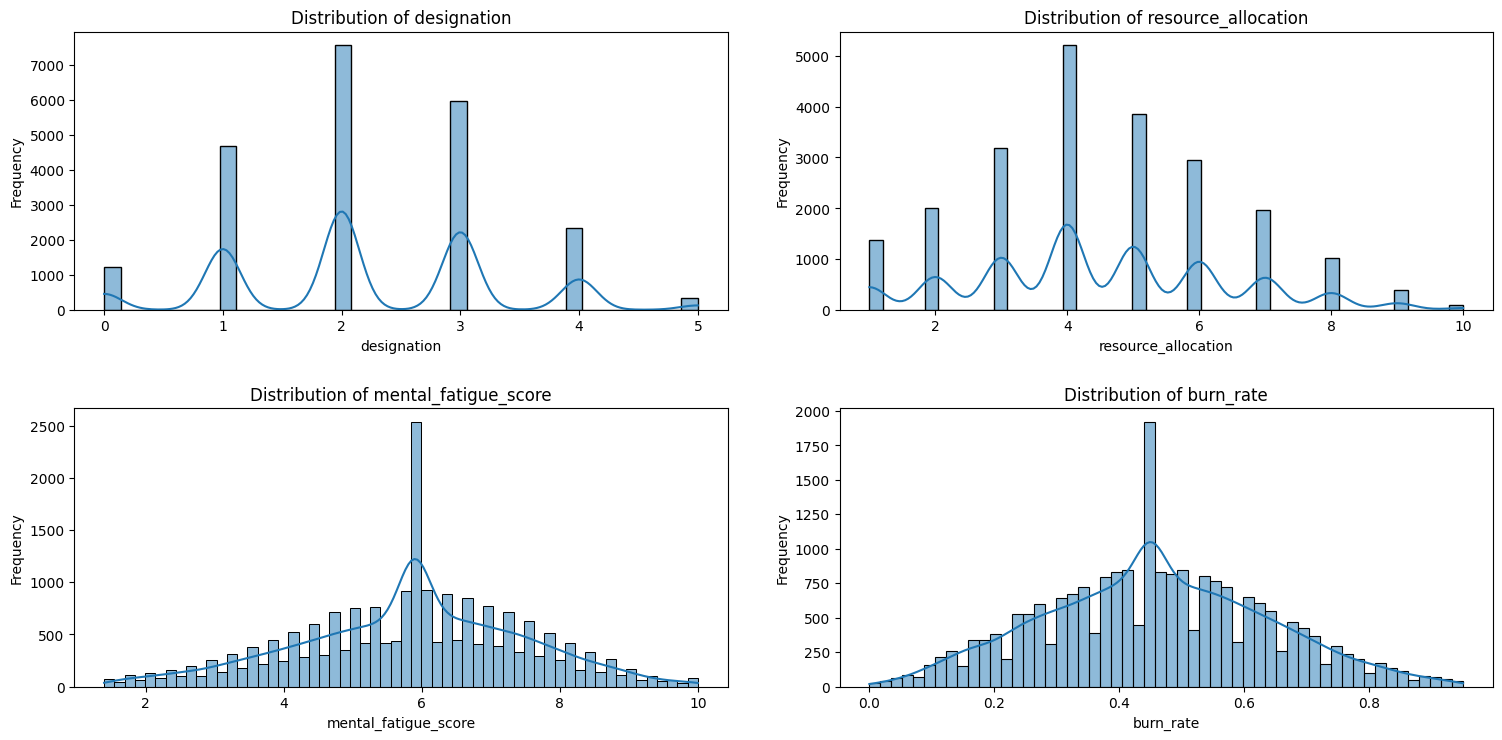

In [43]:
# creating a function to plot the distribution of the variables
def univariate_analysis(train_df):
    num_cols = len(train_df.columns)
    fig, axes = plt.subplots(nrows=(num_cols // 3) + 1, ncols=2, figsize=(16, 4 * ((num_cols // 3) + 1)))
    fig.tight_layout(pad=5.0)

    axes = axes.flatten() # Flatten axes array for easy iteration

    for i, col_name in enumerate(numerical_columns):
        sns.histplot(data=train_df, x=col_name, kde=True, ax=axes[i]) # We used KDE for a smooth distribution curve
        axes[i].set_title(f'Distribution of {col_name}')
        axes[i].set_xlabel(col_name)
        axes[i].set_ylabel('Frequency')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.show()

univariate_analysis(train_df)

**Insight**: `mental_fatigue_score` and `burn_rate` showed a shape of Gaussian (normal) distribution with a unimodal spike at the center of each distribution. `designation` and `resource_allocation` also shows close to zero skewness. This shows us that the dataset is good for a regression model.

In [44]:
# let's create a function for categorical analysis
cat_df = train_df.select_dtypes(include=['object'])

def cat_univariate_analysis(discrete_data):
    for col_name in discrete_data:
        print("*"*5, col_name, "*"*5)
        print(discrete_data[col_name].agg(['count', 'nunique', 'unique']))
        print()
        print('Value Counts: \n', discrete_data[col_name].value_counts())
        print()

cat_univariate_analysis(cat_df)

***** gender *****
count               22076
nunique                 2
unique     [Female, Male]
Name: gender, dtype: object

Value Counts: 
 gender
Female    11534
Male      10542
Name: count, dtype: int64

***** company_type *****
count                   22076
nunique                     2
unique     [Service, Product]
Name: company_type, dtype: object

Value Counts: 
 company_type
Service    14401
Product     7675
Name: count, dtype: int64

***** work_remotely *****
count          22076
nunique            2
unique     [No, Yes]
Name: work_remotely, dtype: object

Value Counts: 
 work_remotely
Yes    11899
No     10177
Name: count, dtype: int64



***** proportions of  gender *****


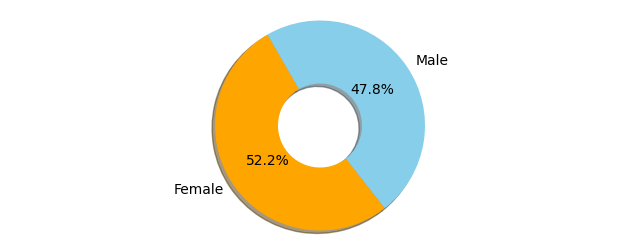

***** proportions of  company_type *****


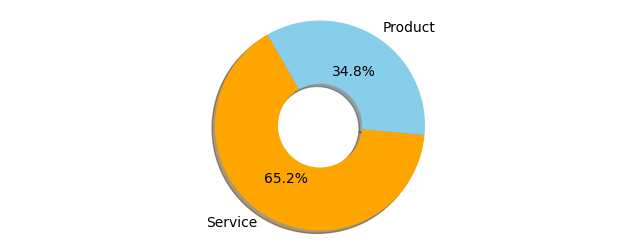

***** proportions of  work_remotely *****


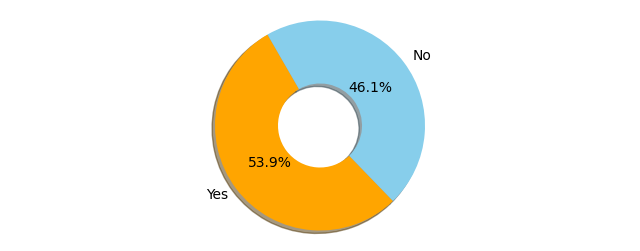

In [45]:
## Plot the proportions of each unique values in the train dataset

# pie chart of borrower's home type
cat_features = train_df.select_dtypes(include='object').columns

for col_name in cat_features:
    col_counts = train_df[col_name].value_counts()
    print("*"*5, "proportions of ", col_name, "*"*5)
    colors = ['orange', 'skyblue']
    
    plt.figure(figsize=(8, 3))
    plt.pie(col_counts.values, labels=col_counts.index, colors=colors,
    autopct='%1.1f%%', shadow=True, startangle=120, wedgeprops=dict(width=0.6))
    # print()
    
    plt.axis('equal')
    plt.show()

## Bivariate and Multivariate Analysis

### Scatter plots of Numerical variables vs Target Variable

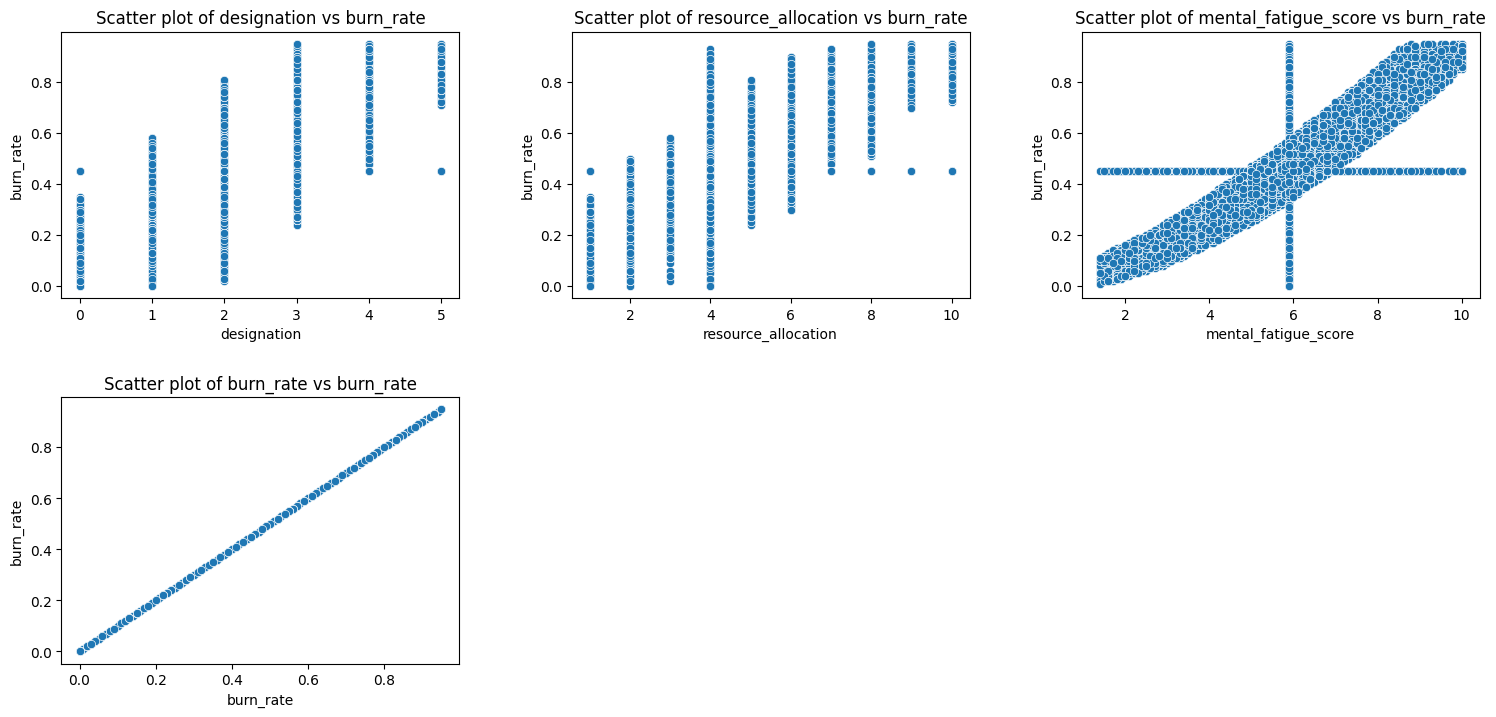

In [47]:
# creating a function to plot the Scatter plots of the numerical variables vs the target variable
num_df = train_df.select_dtypes(include=['int64', 'float64'])

def bivariate_analysis(num_df):
    num_cols = len(num_df.columns)
    fig, axes = plt.subplots(nrows=(num_cols // 3) + 1, ncols=3, figsize=(16, 4 * ((num_cols // 3) + 1)))
    fig.tight_layout(pad=5.0)

    axes = axes.flatten() # Flatten axes array for easy iteration

    for i, col_name in enumerate(num_df):
        sns.scatterplot(data=num_df, x=col_name, y='burn_rate', ax=axes[i])
        axes[i].set_title(f'Scatter plot of {col_name} vs burn_rate')
        axes[i].set_xlabel(col_name)
        axes[i].set_ylabel('burn_rate')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.show()

bivariate_analysis(num_df)

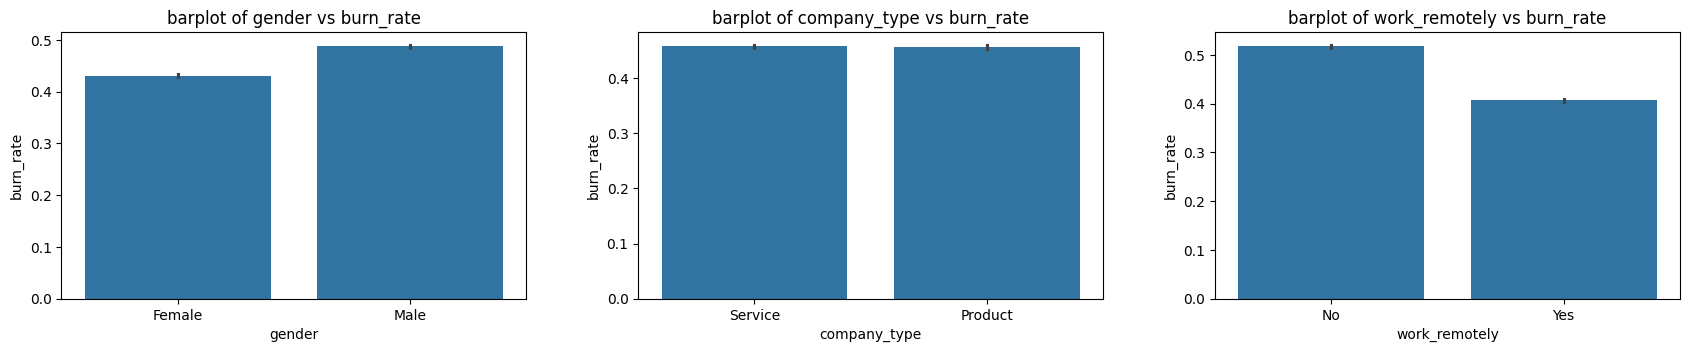

In [48]:
cat_df = train_df.select_dtypes(include=['object']).columns

# creating a function to plot the distribution of the variables
def bivariate_analysis(train_df):
    cat_cols = len(cat_df)
    fig, axes = plt.subplots(nrows=(cat_cols // 3) + 1, ncols=3, figsize=(18, 4 * ((cat_cols // 3) + 1)))
    fig.tight_layout(pad=5.0)

    axes = axes.flatten() # Flatten axes array for easy iteration

    for i, col_name in enumerate(cat_df):
        sns.barplot(data=train_df, x=col_name, y='burn_rate', ax=axes[i])
        axes[i].set_title(f'barplot of {col_name} vs burn_rate')
        axes[i].set_xlabel(col_name)
        axes[i].set_ylabel('burn_rate')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.show()

bivariate_analysis(train_df)

**Insight**: This barplot analysis shows us that people who burn out more is the `Male` gender and people who doesn't work remotely

In [49]:
# linear relationship between numerical variables and the target variable (premium_amount)
train_df.corr(numeric_only=True)['burn_rate'].sort_values(ascending=False)

burn_rate               1.000000
mental_fatigue_score    0.868019
resource_allocation     0.795899
designation             0.696532
Name: burn_rate, dtype: float64

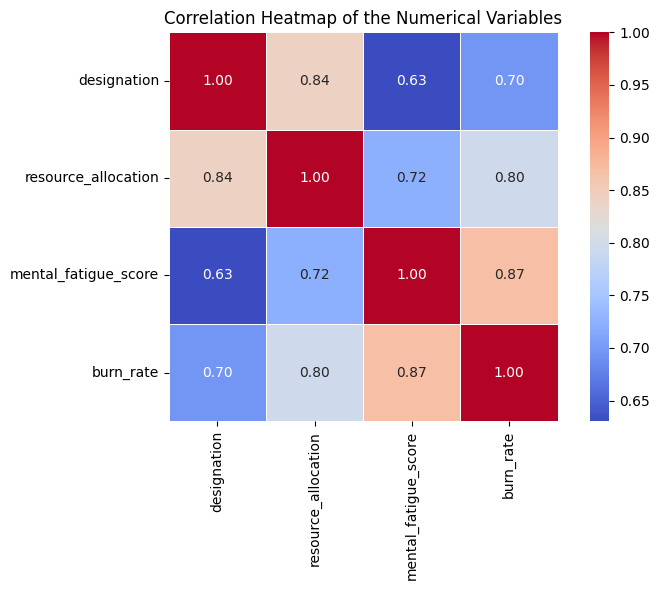

In [50]:
# Using heatmap to show correlation matrix
corr = train_df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, square=True)
plt.title("Correlation Heatmap of the Numerical Variables")

plt.tight_layout()
plt.show()

### Boxplot of categorical variables vs numerical variable (target variable)

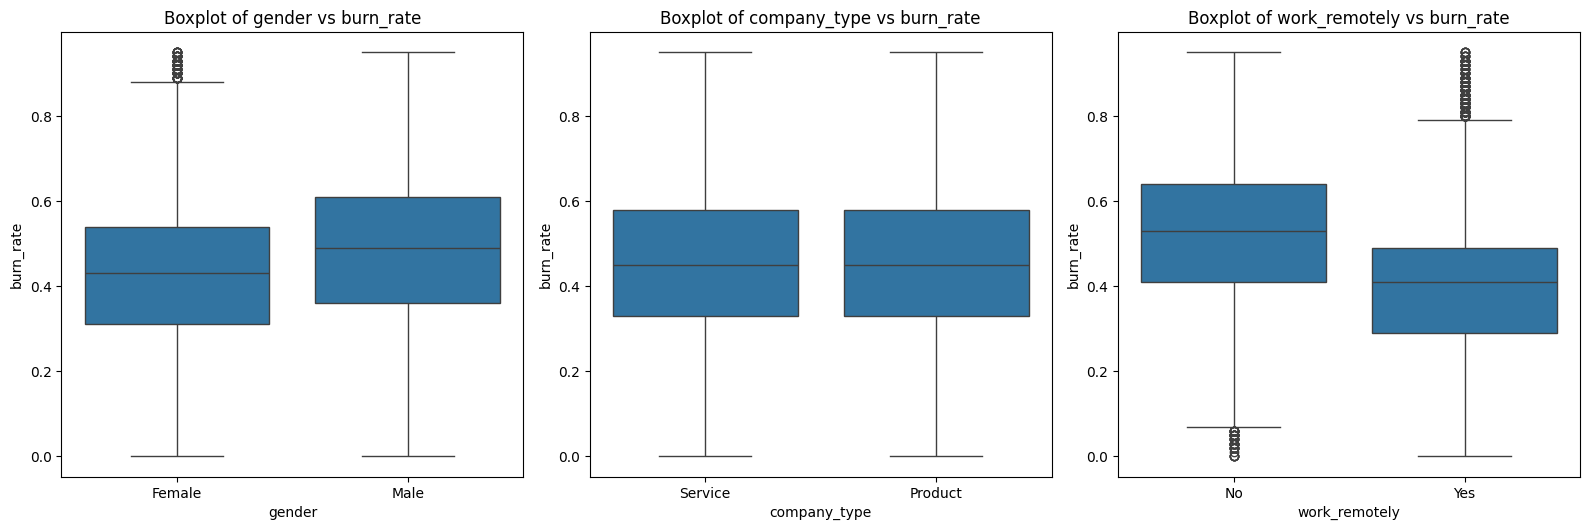

In [51]:
def bivariate_analysis(train_df, target='burn_rate'):
    # Select only categorical features (excluding the target if it's categorical)
    cat_cols = train_df.select_dtypes(include=['object', 'category']).columns
    if target in cat_cols:
        cat_cols = cat_cols.drop(target)

    num_plots = len(cat_cols)
    rows = (num_plots // 3) + 1
    
    fig, axes = plt.subplots(nrows=rows, ncols=3, figsize=(16, 5 * rows))
    axes = axes.flatten()

    for i, col_name in enumerate(cat_cols):
        sns.boxplot(data=train_df, x=col_name, y=target, ax=axes[i])
        axes[i].set_title(f'Boxplot of {col_name} vs {target}')

    # Remove extra subplots if any
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

bivariate_analysis(train_df, target='burn_rate')

### Pairplot of Numerical Variables

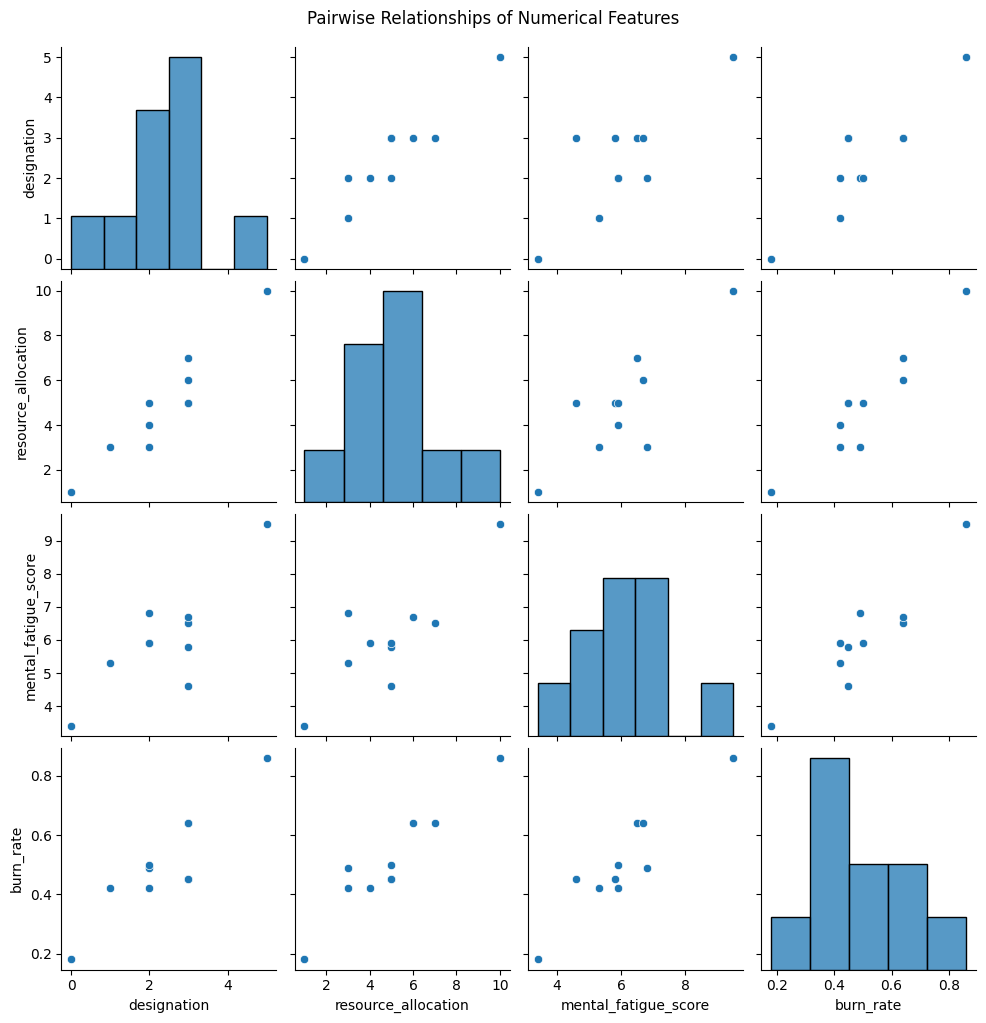

In [52]:
# Select only numerical columns for the pairplot
numerical_cols = train_df.select_dtypes(include=['number']).columns

# Plot pairplot (sample data to avoid crashing)
sns.pairplot(train_df[numerical_cols].sample(10, random_state=42))  # Sampling to reduce rendering time
plt.suptitle('Pairwise Relationships of Numerical Features', y=1.02)
plt.show()

## Feature Engineering and Encoding

In [208]:
train_df.head()

,date_of_joining,gender,company_type,work_remotely,designation,resource_allocation,mental_fatigue_score,burn_rate
employee_id,,,,,,,,
fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,4.0,5.8,0.49
fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20
fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52


In [53]:
# Create 'Tenure' feature in years

today = pd.Timestamp.today()
train_df['tenure'] = (today - train_df['date_of_joining']).dt.days // 365

In [54]:
train_df[['date_of_joining', 'tenure']].head()

,date_of_joining,tenure
employee_id,,
fffe32003000360033003200,2008-09-30,16
fffe3700360033003500,2008-11-30,16
fffe31003300320037003900,2008-03-10,17
fffe32003400380032003900,2008-11-03,16
fffe31003900340031003600,2008-07-24,16


In [55]:
# Tenure months feature
train_df['tenure_months'] = (today - train_df['date_of_joining']).dt.days // 30

In [56]:
train_df[['date_of_joining', 'tenure', 'tenure_months']].head()

,date_of_joining,tenure,tenure_months
employee_id,,,
fffe32003000360033003200,2008-09-30,16,204
fffe3700360033003500,2008-11-30,16,202
fffe31003300320037003900,2008-03-10,17,211
fffe32003400380032003900,2008-11-03,16,203
fffe31003900340031003600,2008-07-24,16,206


In [214]:
train_df.dtypes

date_of_joining         datetime64[ns]
gender                          object
company_type                    object
work_remotely                   object
designation                    float64
resource_allocation            float64
mental_fatigue_score           float64
burn_rate                      float64
tenure                           int64
tenure_months                    int64
dtype: object

In [57]:
# Engineer feature to check if an employee just newly joined the company
train_df['is_new_joiner'] = train_df['tenure'] < 1

In [58]:
train_df['is_new_joiner'].value_counts()

is_new_joiner
False    22076
Name: count, dtype: int64

In [59]:
# Multiply Mental Fatigue Score and Resource Allocation to capture interaction feature
train_df['fatigue_allocation_interaction'] = train_df['mental_fatigue_score'] * train_df['resource_allocation']

In [60]:
train_df[['mental_fatigue_score', 'resource_allocation', 'fatigue_allocation_interaction']].head()

,mental_fatigue_score,resource_allocation,fatigue_allocation_interaction
employee_id,,,
fffe32003000360033003200,3.8,3.0,11.4
fffe3700360033003500,5.0,2.0,10.0
fffe31003300320037003900,5.8,4.0,23.2
fffe32003400380032003900,2.6,1.0,2.6
fffe31003900340031003600,6.9,7.0,48.3


In [61]:
# Flag higher-level employees (e.g., Designation ≥ 4)
train_df['is_high_designation'] = train_df['designation'] >= 4

In [62]:
train_df[['designation', 'is_high_designation']].head()

,designation,is_high_designation
employee_id,,
fffe32003000360033003200,2.0,False
fffe3700360033003500,1.0,False
fffe31003300320037003900,2.0,False
fffe32003400380032003900,1.0,False
fffe31003900340031003600,3.0,False


In [63]:
train_df['is_high_designation'].value_counts()

is_high_designation
False    19414
True      2662
Name: count, dtype: int64

In [64]:
# Normalized Resource Allocation (0 to 1)
train_df['resource_allocation_normalized'] = train_df['resource_allocation'] / train_df['resource_allocation'].max()

In [65]:
train_df[['resource_allocation', 'resource_allocation_normalized']]

,resource_allocation,resource_allocation_normalized
employee_id,,
fffe32003000360033003200,3.0,0.3
fffe3700360033003500,2.0,0.2
fffe31003300320037003900,4.0,0.4
fffe32003400380032003900,1.0,0.1
fffe31003900340031003600,7.0,0.7
...,...,...
fffe31003500370039003100,3.0,0.3
fffe33003000350031003800,6.0,0.6
fffe390032003000,7.0,0.7


In [67]:
train_df.columns

Index(['date_of_joining', 'gender', 'company_type', 'work_remotely',
       'designation', 'resource_allocation', 'mental_fatigue_score',
       'burn_rate', 'tenure', 'tenure_months', 'is_new_joiner',
       'fatigue_allocation_interaction', 'is_high_designation',
       'resource_allocation_normalized'],
      dtype='object')

In [68]:
test_df.dtypes

date_of_joining         datetime64[ns]
gender                          object
company_type                    object
work_remotely                   object
designation                    float64
resource_allocation            float64
mental_fatigue_score           float64
dtype: object

In [69]:
test_df.columns

Index(['date_of_joining', 'gender', 'company_type', 'work_remotely',
       'designation', 'resource_allocation', 'mental_fatigue_score'],
      dtype='object')

In [70]:
# Feature Engineering in the test dataframe
today = pd.Timestamp.today()

for df in [test_df]:
    df['tenure'] = (today - test_df['date_of_joining']).dt.days // 365
    df['tenure_months'] = (today - test_df['date_of_joining']).dt.days // 30
    df['is_new_joiner'] = test_df['tenure'] < 1
    df['fatigue_allocation_interaction'] = test_df['mental_fatigue_score'] * test_df['resource_allocation']
    df['is_high_designation'] = test_df['designation'] >= 4
    df['resource_allocation_normalized'] = test_df['resource_allocation'] / test_df['resource_allocation'].max()

In [71]:
test_df.columns

Index(['date_of_joining', 'gender', 'company_type', 'work_remotely',
       'designation', 'resource_allocation', 'mental_fatigue_score', 'tenure',
       'tenure_months', 'is_new_joiner', 'fatigue_allocation_interaction',
       'is_high_designation', 'resource_allocation_normalized'],
      dtype='object')

In [253]:
test_df.head()

,date_of_joining,gender,company_type,work_remotely,designation,resource_allocation,mental_fatigue_score,tenure,is_new_joiner,fatigue_allocation_interaction,is_high_designation,tenure_months,resource_allocation_normalized
employee_id,,,,,,,,,,,,,
fffe31003300390039003000,2008-12-10,Female,Service,No,2.0,5.0,7.7,16,False,38.5,False,202,0.5
fffe31003300310037003800,2008-08-14,Female,Product,Yes,1.0,2.0,5.2,16,False,10.4,False,206,0.2
fffe33003400380035003900,2008-11-13,Male,Product,Yes,1.0,3.0,5.9,16,False,17.7,False,203,0.3
fffe3100370039003200,2008-02-07,Female,Service,No,3.0,6.0,4.6,17,False,27.6,False,212,0.6
fffe32003600390036003700,2008-07-17,Female,Product,No,2.0,5.0,6.4,17,False,32.0,False,207,0.5


## Model Development

In [72]:
# convert boolean types to numeric integers (1/0)
train_df['is_new_joiner'] = train_df['is_new_joiner'].astype(int)
train_df['is_high_designation'] = train_df['is_high_designation'].astype(int)
test_df['is_new_joiner'] = test_df['is_new_joiner'].astype(int)
test_df['is_high_designation'] = test_df['is_high_designation'].astype(int)

In [73]:
# Segregate independent and target variables in the train dataset
X = train_df.drop(columns=['date_of_joining', 'burn_rate'])
y = train_df['burn_rate']

In [74]:
X.head()

,gender,company_type,work_remotely,designation,resource_allocation,mental_fatigue_score,tenure,tenure_months,is_new_joiner,fatigue_allocation_interaction,is_high_designation,resource_allocation_normalized
employee_id,,,,,,,,,,,,
fffe32003000360033003200,Female,Service,No,2.0,3.0,3.8,16,204,0,11.4,0,0.3
fffe3700360033003500,Male,Service,Yes,1.0,2.0,5.0,16,202,0,10.0,0,0.2
fffe31003300320037003900,Female,Product,Yes,2.0,4.0,5.8,17,211,0,23.2,0,0.4
fffe32003400380032003900,Male,Service,Yes,1.0,1.0,2.6,16,203,0,2.6,0,0.1
fffe31003900340031003600,Female,Service,No,3.0,7.0,6.9,16,206,0,48.3,0,0.7


In [260]:
y.head()

employee_id
fffe32003000360033003200    0.16
fffe3700360033003500        0.36
fffe31003300320037003900    0.49
fffe32003400380032003900    0.20
fffe31003900340031003600    0.52
Name: burn_rate, dtype: float64

In [265]:
X.dtypes

gender                             object
company_type                       object
work_remotely                      object
designation                       float64
resource_allocation               float64
mental_fatigue_score              float64
tenure                              int64
tenure_months                       int64
is_new_joiner                       int64
fatigue_allocation_interaction    float64
is_high_designation                 int64
resource_allocation_normalized    float64
dtype: object

### Feature Encoding

In [75]:
from sklearn.preprocessing import LabelEncoder

# Define categorical columns
cat_cols = ['gender', 'work_remotely', 'company_type']

# Store encoders (for later use)
label_encoders = {}

# Loop through each categorical column
for col in cat_cols:
    label_encoder = LabelEncoder()
    X[col] = label_encoder.fit_transform(X[col])
    test_df[col] = label_encoder.transform(test_df[col])
    label_encoders[col] = label_encoder  # Save encoder

In [269]:
X.head()

,gender,company_type,work_remotely,designation,resource_allocation,mental_fatigue_score,tenure,tenure_months,is_new_joiner,fatigue_allocation_interaction,is_high_designation,resource_allocation_normalized
employee_id,,,,,,,,,,,,
fffe32003000360033003200,0,1,0,2.0,3.0,3.8,16,204,0,11.4,0,0.3
fffe3700360033003500,1,1,1,1.0,2.0,5.0,16,202,0,10.0,0,0.2
fffe31003300320037003900,0,0,1,2.0,4.0,5.8,17,211,0,23.2,0,0.4
fffe32003400380032003900,1,1,1,1.0,1.0,2.6,16,203,0,2.6,0,0.1
fffe31003900340031003600,0,1,0,3.0,7.0,6.9,16,206,0,48.3,0,0.7


In [270]:
test_df.head()

,date_of_joining,gender,company_type,work_remotely,designation,resource_allocation,mental_fatigue_score,tenure,is_new_joiner,fatigue_allocation_interaction,is_high_designation,tenure_months,resource_allocation_normalized
employee_id,,,,,,,,,,,,,
fffe31003300390039003000,2008-12-10,0,1,0,2.0,5.0,7.7,16,0,38.5,0,202,0.5
fffe31003300310037003800,2008-08-14,0,0,1,1.0,2.0,5.2,16,0,10.4,0,206,0.2
fffe33003400380035003900,2008-11-13,1,0,1,1.0,3.0,5.9,16,0,17.7,0,203,0.3
fffe3100370039003200,2008-02-07,0,1,0,3.0,6.0,4.6,17,0,27.6,0,212,0.6
fffe32003600390036003700,2008-07-17,0,0,0,2.0,5.0,6.4,17,0,32.0,0,207,0.5


In [76]:
# drop the date column from the test dataset
test_df = test_df.drop(columns=['date_of_joining'])

In [272]:
test_df.head()

,gender,company_type,work_remotely,designation,resource_allocation,mental_fatigue_score,tenure,is_new_joiner,fatigue_allocation_interaction,is_high_designation,tenure_months,resource_allocation_normalized
employee_id,,,,,,,,,,,,
fffe31003300390039003000,0,1,0,2.0,5.0,7.7,16,0,38.5,0,202,0.5
fffe31003300310037003800,0,0,1,1.0,2.0,5.2,16,0,10.4,0,206,0.2
fffe33003400380035003900,1,0,1,1.0,3.0,5.9,16,0,17.7,0,203,0.3
fffe3100370039003200,0,1,0,3.0,6.0,4.6,17,0,27.6,0,212,0.6
fffe32003600390036003700,0,0,0,2.0,5.0,6.4,17,0,32.0,0,207,0.5


### Normalization (Standardize numeric values)

In [77]:
X = X.drop(columns=['resource_allocation_normalized'])

In [78]:
test_df = test_df.drop(columns=['resource_allocation_normalized'])

In [79]:
X.columns

Index(['gender', 'company_type', 'work_remotely', 'designation',
       'resource_allocation', 'mental_fatigue_score', 'tenure',
       'tenure_months', 'is_new_joiner', 'fatigue_allocation_interaction',
       'is_high_designation'],
      dtype='object')

In [80]:
from sklearn.preprocessing import StandardScaler

cols_to_scale = ['resource_allocation', 'designation', 'mental_fatigue_score', 'tenure', 'tenure_months', 'fatigue_allocation_interaction']

std_scaler = StandardScaler()

X[cols_to_scale] = std_scaler.fit_transform(X[cols_to_scale])
test_df[cols_to_scale] = std_scaler.transform(test_df[cols_to_scale])

In [280]:
X

,gender,company_type,work_remotely,designation,resource_allocation,mental_fatigue_score,tenure,tenure_months,is_new_joiner,fatigue_allocation_interaction,is_high_designation
employee_id,,,,,,,,,,,
fffe32003000360033003200,0,1,0,-0.185221,-0.779414,-1.238478,-1.108298,-0.850866,0,-0.959087,0
fffe3700360033003500,1,1,1,-1.091257,-1.299999,-0.510733,-1.108298,-1.416708,0,-1.037333,0
fffe31003300320037003900,0,0,1,-0.185221,-0.258830,-0.025570,0.902285,1.129583,0,-0.299589,0
fffe32003400380032003900,1,1,1,-1.091257,-1.820583,-1.966223,-1.108298,-1.133787,0,-1.450917,0
fffe31003900340031003600,0,1,0,0.720815,1.302923,0.641529,-1.108298,-0.285023,0,1.103242,0
...,...,...,...,...,...,...,...,...,...,...,...
fffe31003500370039003100,0,1,0,-1.091257,-0.779414,0.035075,-1.108298,-1.699629,0,-0.606982,0
fffe33003000350031003800,0,0,1,0.720815,0.782339,0.520238,0.902285,1.412505,0,0.650536,0
fffe390032003000,1,1,1,0.720815,1.302923,0.035075,-1.108298,-1.133787,0,0.712014,0


In [281]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22076 entries, fffe32003000360033003200 to fffe3400350031003800
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   gender                          22076 non-null  int64  
 1   company_type                    22076 non-null  int64  
 2   work_remotely                   22076 non-null  int64  
 3   designation                     22076 non-null  float64
 4   resource_allocation             22076 non-null  float64
 5   mental_fatigue_score            22076 non-null  float64
 6   tenure                          22076 non-null  float64
 7   tenure_months                   22076 non-null  float64
 8   is_new_joiner                   22076 non-null  int64  
 9   fatigue_allocation_interaction  22076 non-null  float64
 10  is_high_designation             22076 non-null  int64  
dtypes: float64(6), int64(5)
memory usage: 2.5+ MB


In [282]:
test_df.head()

,gender,company_type,work_remotely,designation,resource_allocation,mental_fatigue_score,tenure,is_new_joiner,fatigue_allocation_interaction,is_high_designation,tenure_months
employee_id,,,,,,,,,,,
fffe31003300390039003000,0,1,0,-0.185221,0.261754,1.126692,-1.108298,0,0.555523,0,-1.416708
fffe31003300310037003800,0,0,1,-1.091257,-1.299999,-0.389443,-1.108298,0,-1.014977,0,-0.285023
fffe33003400380035003900,1,0,1,-1.091257,-0.779414,0.035075,-1.108298,0,-0.606982,0,-1.133787
fffe3100370039003200,0,1,0,0.720815,0.782339,-0.753315,0.902285,0,-0.053674,0,1.412505
fffe32003600390036003700,0,0,0,-0.185221,0.261754,0.338302,0.902285,0,0.192240,0,-0.002102


In [81]:
# Train/Validation Split for local evaluation
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_val.shape)
print(y_train.shape, y_val.shape)

(17660, 11) (4416, 11)
(17660,) (4416,)


## Model Training and Evaluation

In [82]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dictionary of models to be trained and evaluated
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    'KNN Regressor': KNeighborsRegressor(),
    "Support Vector Regressor": SVR()
}

# Store results
results = []

# Loop through models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    RMSE = mean_squared_error(y_val, y_pred)
    MAE = mean_absolute_error(y_val, y_pred)
    R2 = r2_score(y_val, y_pred)

    results.append((name, RMSE, MAE, R2))

# Show baseline results
results_df = pd.DataFrame(results, columns=["Model", "RMSE", "MAE", "R2"]).sort_values(by='R2', ascending=False)
print("Baseline Model Results:")
print(results_df)

Baseline Model Results:
                      Model      RMSE       MAE        R2
2         Gradient Boosting  0.004948  0.052816  0.844482
4  Support Vector Regressor  0.005354  0.055591  0.831707
0         Linear Regression  0.005726  0.055472  0.820038
1             Random Forest  0.006076  0.057767  0.809022
3             KNN Regressor  0.006253  0.059577  0.803445


## Interpretation
Based on our model training and evaluation on multiple regression algorithms, `Gradient Boosting` performed better than the rest of the models with an `RMSE` of `0.004958`, `MAE` of `0.052841`, and `R2` of `0.844162`.

### Best Performing Model: Gradient Boosting
Why we chose the model?
- Highest R² (0.844) — best explains the variance in our target variable.

- Lowest RMSE (0.00496) — smallest average squared prediction error.

- Lowest MAE (0.05284) — lowest average magnitude of prediction error.

**We'll now go ahead to fine-tune this model using `hyperparameter tuning` technique**

In [83]:
### Retraining Gradient Boosting (Best Model)
from sklearn.ensemble import GradientBoostingRegressor

# Merge train and validation data
X_full = pd.concat([X_train, X_val])
y_full = pd.concat([y_train, y_val])

# Retrain model on full data
best_model = GradientBoostingRegressor()
best_model.fit(X_full, y_full)

GradientBoostingRegressor()

### Hyperparameter Tuning (Fine-tuning the best model, *`"GradientBoostingRegressor"`*)

In [85]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# define hyperparameters
param_dist = {
    'n_estimators': randint(100, 301),
    'max_depth': randint(3, 6),
    'learning_rate': uniform(0.01, 0.1),
    'subsample': uniform(0.8, 0.2)
}

random_search = RandomizedSearchCV(
    GradientBoostingRegressor(),
    param_distributions=param_dist,
    n_iter=20,  # test only 20 random combinations
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_full, y_full)
tuned_model = random_search.best_estimator_


Fitting 3 folds for each of 20 candidates, totalling 60 fits


### Re-evaluating our re-trained selected model using *RSME*, *MAE*, and *R2* Metrics

In [88]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = tuned_model.predict(X_val)

RMSE = mean_squared_error(y_val, y_pred)
MAE = mean_absolute_error(y_val, y_pred)
R2 = r2_score(y_val, y_pred)

print(f"Re-evaluated RMSE: {RMSE:.4f}")
print(f"Re-evaluated MAE:  {MAE:.4f}")
print(f"Re-evaluated R²:   {R2:.4f}")

Re-evaluated RMSE: 0.0047
Re-evaluated MAE:  0.0514
Re-evaluated R²:   0.8533


## Interpretation of the Re-evaluated Results based on the metrics

### Re-evaluated Model Performance
- RMSE (Root Mean Squared Error): 0.0047

- MAE (Mean Absolute Error): 0.0514

- R2 (R-squared score): 0.8533

## Interpretation of Each Metric:
**RMSE** = 0.0047
- Measures average magnitude of error, but penalizes large errors more due to squaring.

- A lower RMSE means our model’s predictions are very close to the actual values.

- 0.0047 is a small error, suggesting high precision.

**MAE** = 0.0514
- Measures the average absolute error between predicted and actual values.

- Unlike RMSE, it treats all errors equally (no squaring).

- Again, very low value, which reinforces that our model is making small, consistent errors.

**R2 Score** = 0.8533 <br>
Tells us how much variance in the target variable is explained by our model.

- Ranges from 0 to 1:

- 0.85 means 85.3% of the variation in the target is explained by the model.

- That’s very good and shows a strong fit.


### Compared to Before Tuning:

| Metric | Before (Best Model - Gradient Boosting) | After Tuning |
|--------|------------------------------------------|--------------|
| RMSE   | 0.004958                                 | **0.0047** (improved ✅) |
| MAE    | 0.052841                                 | **0.0514** (improved ✅) |
| R2     | 0.844162                                 | **0.8533** (improved ✅) |

<hr>

### Prepare a Sumbmission file
Usually contains `ID` and the `Prediction`

In [104]:
# Predict on the test dataset using your final tuned model
y_test_pred = tuned_model.predict(test_df)

# Create a submission DataFrame
submission_df = pd.DataFrame({
    'Employee ID': test_df.index,           # Or use 'ID' if your test data has an ID column
    'Burn Rate': y_test_pred
})

submission_df.set_index('Employee ID', inplace=True)

# 3. Save to CSV
submission_df.to_csv('submission.csv', index=False)

# Show the top 5 rows
submission_df.head()

,Burn Rate
Employee ID,
fffe31003300390039003000,0.601506
fffe31003300310037003800,0.351334
fffe33003400380035003900,0.383178
fffe3100370039003200,0.409267
fffe32003600390036003700,0.524362


## Explanation

### Why This Submission file is Important
- This is usually required for model deployment or competition submission, like on Kaggle or during internal evaluations.

- It makes it easy for stakeholders, evaluators, or a platform to match each prediction with the corresponding employee using their ID.

## Feature Importance

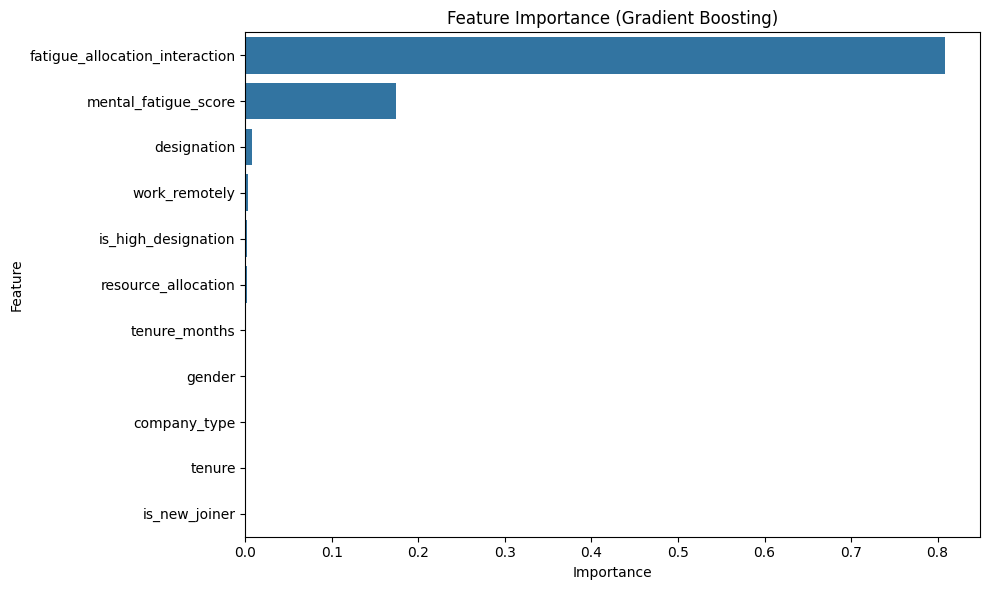

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances
importances = tuned_model.feature_importances_

# Create a DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': X_full.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance (Gradient Boosting)')

plt.tight_layout()
plt.show()

In [102]:
feature_importance_df

,Feature,Importance
9,fatigue_allocation_interaction,0.808587
5,mental_fatigue_score,0.174596
3,designation,0.007661
2,work_remotely,0.003520
10,is_high_designation,0.001738
4,resource_allocation,0.001738
7,tenure_months,0.001027
0,gender,0.000801
1,company_type,0.000255
6,tenure,0.000078


## Interpretation of the Feature Importance Result

### What Does Feature Importance Mean?
Each feature importance score represents how much a given feature contributes to reducing error (loss) in our model. The higher the importance, the more the model relies on that feature to make accurate predictions. A feature with low or zero importance means it's either redundant or not useful in the decision-making process of the model.

Hence, the highest importance score of the `fatigue_allocation_interaction (0.808587)` feature shows that the feature is the most influential, and our model relies on it the most. The `mental_fatigue_score (0.174596)` and `designation (0.007661)` features show that they are still important, but less than the top feature. Other features with lower scores are less relevant. Features with zero importance scores show that they are not useful for predictions, and may be removed in feature selection.

The sum of all feature importance scores equals 1.0, as they are normalized.

### Using SHAP (SHapley Additive exPlanations)
SHAP gives individual explanations for predictions, using game theory to calculate how much each feature contributes.

100%|===================| 22054/22076 [07:12<00:00]        

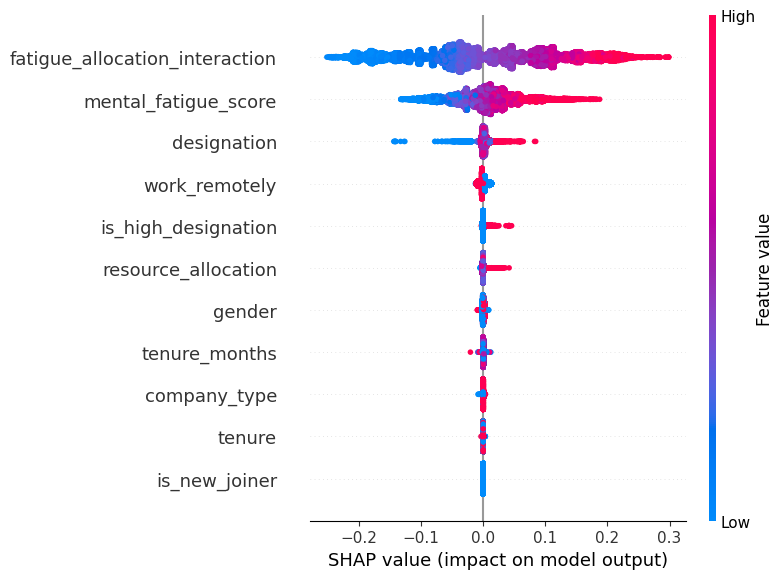

In [94]:
import shap

# Create the SHAP explainer
explainer = shap.Explainer(tuned_model, X_full)

# Calculate SHAP values
shap_values = explainer(X_full)

# Summary plot (global importance)
shap.summary_plot(shap_values, X_full)

# Optional: Force plot for a single prediction
# shap.force_plot(explainer.expected_value, shap_values[0], X_full.iloc[0])

## Save the Model for Deployment

In [107]:
import joblib

# 1. Save the tuned model
joblib.dump(tuned_model, 'model.pkl')

# 2. Save the scaler
joblib.dump(std_scaler, 'scaler.pkl')

# 3. Save label encoders (assuming you stored them in a dict)
for col, label_encoder in label_encoders.items():
    joblib.dump(label_encoder, f'label_encoder_{col}.pkl')

print("Saved model, scaler, and encoders successfully!")

Saved model, scaler, and encoders successfully!


<hr>

# Final Report Summarizing Key Findings and Predictions

## Employee Burn Rate Prediction Report
### Project Overview
This project aimed to develop a machine learning model to predict employee burn rate based on various demographic, work-related, and HR features. The goal was to assist HR teams in identifying employees at risk of burnout and taking proactive measures.

### Data Summary

- Training Set: Included features such as Gender, Company Type, WFH Setup, Designation, Resource Allocation, etc.

- Target Variable: Burn Rate (continuous value between 0 and 1).

- Missing Values: Handled through imputation strategies for both categorical and numeric variables.

- Feature Engineering:

    - Extracted tenure and tenure_months from Date of Joining.
 
    - Extracted fatigue_allocation_interaction from mental_fatigue_score and resource_allocation

    - Encoded categorical variables using LabelEncoder.

    - Scaled numerical features using StandardScaler.

### Model Development
Five regression models were trained and evaluated:

| Model                    | RMSE     | MAE     | R² Score |
|--------------------------|----------|---------|----------|
| **Gradient Boosting**    | 0.00496  | 0.05284 | **0.8442** |
| Support Vector Regressor | 0.00536  | 0.05565 | 0.8317  |
| Linear Regression        | 0.00573  | 0.05547 | 0.8200  |
| Random Forest            | 0.00608  | 0.05792 | 0.8090  |
| KNN Regressor            | 0.00629  | 0.05961 | 0.8024  |


**Best Performing Model**: Gradient Boosting Regressor

### Hyperparameter Tuning
- Technique: Randomized Search with 3-fold cross-validation

- Best Estimator: Tuned Gradient Boosting Regressor

- Retraining: Model was retrained on the full training data using optimal parameters.

### Final Model Performance
After retraining with tuned hyperparameters:

- RMSE: 0.0047

- MAE: 0.0514

- R2 Score: 0.8533

**The improvement in R2 suggests better model generalization and performance.**

### Feature Importance Analysis
Using feature_importances_:

**Top contributing features to employee burn rate**:

1. Fatigue Allocation Interaction

2. Mental Fatigue Score

3. Resource Allocation

4. Designation

5. WFH Setup Available

6. Company Type

**Mental Fatigue Score is the most significant driver of employee burnout**.

### Final Prediction & Submission
- Predictions were made on the test dataset using the tuned model.

- Output was saved in a submission file: submission_df.csv with columns:

    - Employee ID

    - Burn Rate

## Key Takeaways
- A high-performing `Gradient Boosting` model was built to predict burn rates with good accuracy.

- Fatigue Allocation Interaction, Mental fatigue, resource allocation, and work-from-home setup availability are critical indicators.

- The model can assist HR in early identification of burnout risks and drive better employee support strategies.

<hr>

# Actionable Recommendations Based on Our Data Insights, To Mitigate Employee Burn Out

Based on the feature importance scores, here’s a breakdown and some actionable recommendations to consider, to mitigate Employee Burnout:

## Feature Importance Summary

| Rank | Feature                        | Importance | Interpretation |
|------|--------------------------------|------------|----------------|
| 1    | `fatigue_allocation_interaction` | **0.8086**  | Most significant factor. A combined effect of mental fatigue and resource allocation. |
| 2    | `mental_fatigue_score`        | **0.1746**  | Indicates the direct impact of employee fatigue. |
| 3    | `designation`                 | 0.0077     | Job level or role influences output slightly. |
| 4    | `work_remotely`               | 0.0035     | Working from home has minor influence. |
| 5    | `is_high_designation`         | 0.0017     | Seniority slightly affects performance. |
| 6    | `resource_allocation`         | 0.0017     | Alone it has low impact, but interacts strongly with fatigue. |
| 7    | `tenure_months`               | 0.0010     | Time in role has limited effect. |
| 8    | `gender`                      | 0.0008     | Minimal to no effect. |
| 9    | `company_type`                | 0.0003     | Private/public distinction is negligible. |
| 10   | `tenure`                      | 0.0001     | Same as `tenure_months`, very low influence. |
| 11   | `is_new_joiner`              | 0.0000     | No measurable effect in model performance. |

## Actionable Recommendations and Insights
**1. Manage Mental Fatigue and Resource Allocation Together**
Since `fatigue_allocation_interaction` dominates importance `(~80.9%)`, this suggests that how much work a fatigued employee handles is critical.

- **Action**: Use this as a core metric in performance reviews and workload balancing. Consider building a dashboard to monitor this interaction in real-time.

**2. Monitor and Reduce Mental Fatigue**
Direct `mental_fatigue_score` holds a substantial impact `(17.5%)`.

- **Action**: Implement regular employee wellness checks, breaks, mental health programs, or rotate tasks to reduce burnout.

**3. Review Workload for High Designations**
Even though `is_high_designation` and designation aren't top features, they still contribute.

- **Action**: Ensure managerial roles don’t accumulate silent burnout due to higher responsibilities.

**4. Remote Work Has a Mild Influence**
`work_remotely` has a slight effect, likely productivity or fatigue varies by remote status.

- **Action**: Tailor mental health or workload initiatives differently for remote vs. on-site staff.

**5. Ignore Low-Impact Features**
`Gender`, `tenure`, `company_type`, and `new joiner status` contribute nearly nothing.

- **Action**: These shouldn’t be central to policy decisions on productivity or fatigue-related interventions.

<hr>

## REFLECTION QUESTIONS
### 1. What challenges did you face while handling missing data? How did you resolve them?
One of the main challenges encountered while handling missing data was deciding the most appropriate imputation strategy that wouldn’t distort the underlying patterns in the dataset. Some variables had significant portions of missing values, which posed a risk of bias or information loss if not properly handled. To resolve this:

- For numerical features, I applied median imputation where the missing values were replaced with the middle values.

- In cases where domain knowledge suggested it, I also considered dropping non-informative or sparse columns if they were mostly missing and didn’t contribute to model performance.

- There was no missing value in the categorical features.

### 2. Which machine learning algorithm performed the best, and why do you think it outperformed others?

The **Gradient Boosting Regressor** performed the best among all the algorithms evaluated. It outperformed others due to several key strengths:

- **Highest R² (0.844)**: best explains the variance in our target variable.

- **Lowest RMSE (0.00496)**: smallest average squared prediction error.

- **Lowest MAE (0.05284)**: lowest average magnitude of prediction error.

- **Boosting Mechanism**: Gradient Boosting builds models sequentially, where each new model attempts to correct the errors made by the previous one. This iterative process helps reduce bias and leads to high predictive accuracy.
- **Strong Generalization**: Despite its complexity, Gradient Boosting is known for its ability to generalize well on unseen data, especially after proper tuning of hyperparameters.
- **Feature Sensitivity**: The model can capture subtle patterns and interactions between features, which may be missed by linear models or even simpler tree-based models like Random Forest.
- **Customizable Loss Functions**: Gradient Boosting allows for the optimization of various loss functions, making it more flexible for regression tasks with specific error considerations like MAE or RMSE.
- **Regularization Techniques**: Built-in regularization parameters such as learning rate and subsampling help prevent overfitting, especially on datasets with noise or complexity.

Overall, its performance superiority in this case suggests that it was better able to capture the non-linear relationships and subtle feature interactions associated with employee burnout scores.

### 3. If you had access to additional data, what would you like to include, and how might it improve your model?
If I had access to more data, I would consider including:

- **Employee performance ratings**: Could provide insight into how burnout correlates with productivity.

- **Workload metrics (e.g., number of tasks per week)**: These would help quantify the stressors leading to burnout.

- **HR feedback or manager evaluations**: May offer qualitative signals about employee engagement and well-being.

- **Employee engagement or satisfaction scores**: Would provide a more direct measure of emotional exhaustion or detachment.

- **Historical trends**: Time-series data could reveal burnout patterns over time and allow for temporal modeling.